In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 1 (Jun 2022 - May 2023)\Zone_temp_hourly\48190918_Zone_temp_hourly.csv"
df = pd.read_csv(path)
df.head()

,Timestamp,Z11_temp,Z12+13_temp,Z14_temp,Z15+16_temp,Z17_temp,Z1_temp,Z21_temp,Z22+23_temp,Z24_temp,Z25+26+27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z3_temp,Z4_temp,Z5_temp
0,2022-06-01 00:00:00-04:00,21.732333,21.228000,19.698000,21.105000,20.461500,20.808167,22.226833,22.016000,21.988000,22.015333,25.128834,24.859500,23.883333,23.591667,21.129000,21.062500,20.364167
1,2022-06-01 01:00:00-04:00,21.666667,20.980333,19.491667,20.870000,20.100333,20.576667,22.226000,21.847667,21.984000,22.086333,24.793333,24.791333,23.783667,23.636000,21.085000,20.319333,20.014333
2,2022-06-01 02:00:00-04:00,22.026667,21.704667,19.864667,21.540666,20.733833,21.135167,22.275333,21.674333,21.990000,21.859333,24.735000,24.674000,23.658000,23.555333,21.776333,21.443500,20.609833
3,2022-06-01 03:00:00-04:00,22.383333,22.360333,20.620333,22.169333,21.426000,22.633333,22.195000,21.451667,21.547667,21.270000,25.069333,24.522000,23.490333,23.093667,22.093000,22.416000,20.844000
4,2022-06-01 04:00:00-04:00,22.533333,22.599000,20.921333,22.443000,21.736333,23.063000,22.294667,21.731000,21.533667,21.441333,25.288667,24.534000,23.640333,23.442667,22.227667,22.747000,20.987333


In [4]:
df.describe()

,Z11_temp,Z12+13_temp,Z14_temp,Z15+16_temp,Z17_temp,Z1_temp,Z21_temp,Z22+23_temp,Z24_temp,Z25+26+27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z3_temp,Z4_temp,Z5_temp
count,7853.000000,7853.000000,7853.000000,7853.000000,7853.000000,7853.000000,8583.000000,8583.000000,8583.000000,8583.000000,7836.000000,8589.000000,8589.000000,8589.000000,7853.000000,7853.000000,7853.000000
mean,22.723661,23.182852,21.378560,22.739590,22.194442,23.128647,23.043234,22.742745,23.155376,23.055026,24.975342,23.890593,23.068461,23.048834,22.146310,22.939499,21.410397
std,0.954880,0.931770,0.949937,0.947278,1.159198,0.963319,1.212106,1.103371,1.224198,1.115459,0.832521,1.833546,1.510332,1.780578,1.013562,0.867202,1.136397
min,19.253500,19.773794,18.457333,19.740000,19.391333,19.861500,19.159667,19.287334,19.403500,19.469500,22.001667,16.029333,18.891333,17.288500,17.240509,19.878167,18.012833
25%,22.268333,22.802667,20.851333,22.166667,21.421667,22.687000,22.418167,22.203334,22.477833,22.413333,24.517584,22.937666,22.194333,21.850000,21.607667,22.496667,20.623667
50%,22.815000,23.195334,21.261000,22.628000,22.005000,23.117334,22.999000,22.634333,23.108667,23.075000,24.904166,23.630667,22.705000,22.622667,22.173333,23.045333,21.587334
75%,23.241333,23.661667,21.843334,23.253667,22.862000,23.573333,23.573667,23.235333,23.734833,23.595167,25.383333,24.676667,23.628334,23.786333,22.658333,23.432334,22.302333
max,26.923333,27.318000,25.228000,27.056333,26.747000,26.339333,28.440000,27.653333,28.612000,28.473333,27.802666,32.938500,29.398333,29.828333,24.881333,25.283334,23.996000


In [5]:
df.isna().sum()

Timestamp           0
Z11_temp          907
Z12+13_temp       907
Z14_temp          907
Z15+16_temp       907
Z17_temp          907
Z1_temp           907
Z21_temp          177
Z22+23_temp       177
Z24_temp          177
Z25+26+27_temp    177
Z2_temp           924
Z31_temp          171
Z32_temp          171
Z33_temp          171
Z3_temp           907
Z4_temp           907
Z5_temp           907
dtype: int64

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_18288\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


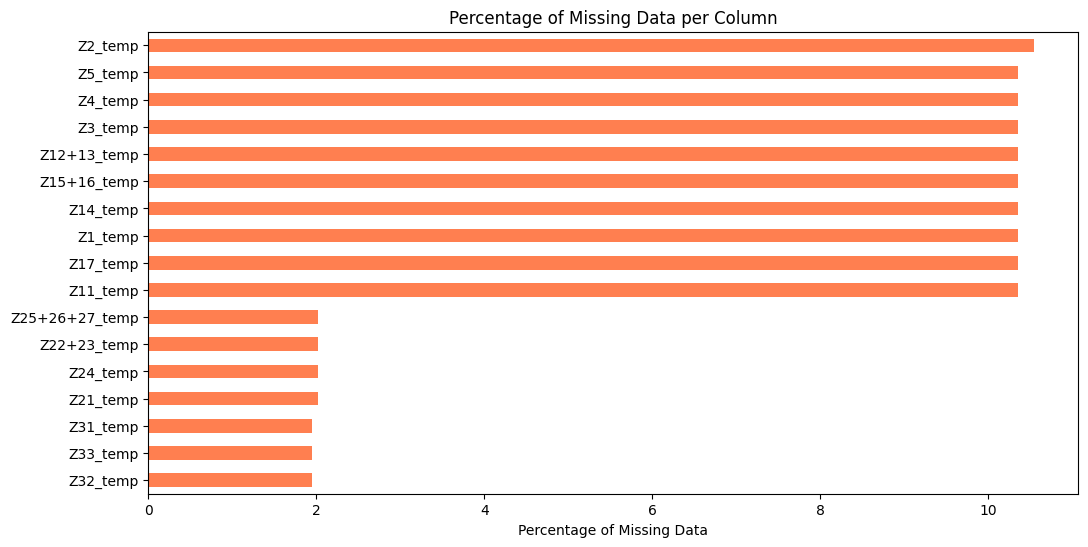

In [7]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]  # Only show columns with missing data
missing_percent.sort_values().plot(kind='barh', figsize=(12, 6), color='coral')
plt.title('Percentage of Missing Data per Column')
plt.xlabel('Percentage of Missing Data')
plt.show()

In [8]:

def handle_missing_data(column):

    # Count the number of missing values in the column
    missing_count = df[column].isna().sum()
    total_rows = len(df)
    
    print(f"Missing values in '{column}': {missing_count} out of {total_rows} ({(missing_count/total_rows)*100:.2f}%)")
    
    # If the missing data is a large percentage (e.g., more than 10%), use interpolation
    if missing_count > total_rows * 0.1:
        print(f"Handling missing data in '{column}' with interpolation...")
        # Interpolate the missing values using linear interpolation
        df[column] = df[column].interpolate(method='linear')
    else:
        # Otherwise, fill the missing data with the median (or mean) of the column
        print(f"Handling missing data in '{column}' with median imputation...")
        df[column] = df[column].fillna(df[column].median())
    
    return df[column]


for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = handle_missing_data(col)

Missing values in 'Z11_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z11_temp' with interpolation...
Missing values in 'Z12+13_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z12+13_temp' with interpolation...
Missing values in 'Z14_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z14_temp' with interpolation...
Missing values in 'Z15+16_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z15+16_temp' with interpolation...
Missing values in 'Z17_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z17_temp' with interpolation...
Missing values in 'Z1_temp': 907 out of 8760 (10.35%)
Handling missing data in 'Z1_temp' with interpolation...
Missing values in 'Z21_temp': 177 out of 8760 (2.02%)
Handling missing data in 'Z21_temp' with median imputation...
Missing values in 'Z22+23_temp': 177 out of 8760 (2.02%)
Handling missing data in 'Z22+23_temp' with median imputation...
Missing values in 'Z24_temp': 177 out of 8760 (2.02%)
Handling missing dat

In [9]:
df.isna().sum()

Z11_temp          0
Z12+13_temp       0
Z14_temp          0
Z15+16_temp       0
Z17_temp          0
Z1_temp           0
Z21_temp          0
Z22+23_temp       0
Z24_temp          0
Z25+26+27_temp    0
Z2_temp           0
Z31_temp          0
Z32_temp          0
Z33_temp          0
Z3_temp           0
Z4_temp           0
Z5_temp           0
dtype: int64

In [10]:
df.shape

(8760, 17)

In [11]:
def treat_outliers_iqr(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    return df_clean
df = treat_outliers_iqr(df)

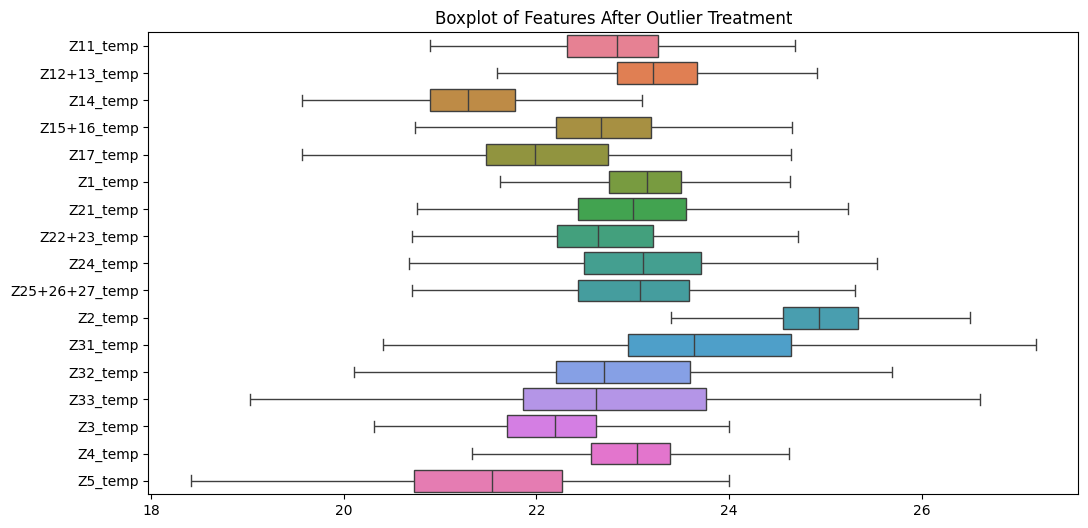

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, orient='h')
plt.title('Boxplot of Features After Outlier Treatment')
plt.show()